In [ ]:
!pip install -q ultralytics
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


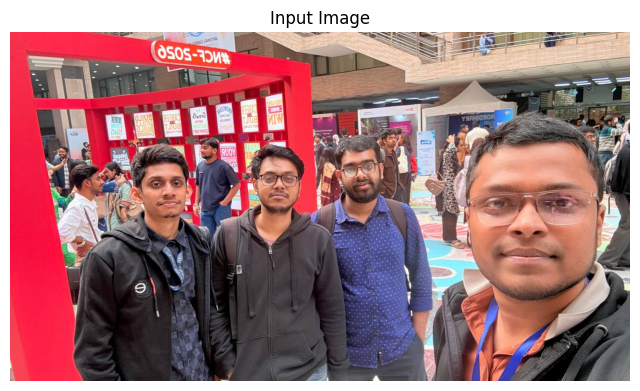

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/PersonRemovalProject/data/test_images/group.jpg"

image_bgr = cv2.imread(image_path)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()


In [ ]:
from ultralytics import YOLO

# Load YOLOv8 model (fast + good)
yolo = YOLO("yolov8n.pt")

results = yolo(image)[0]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 10 persons, 77.9ms
Speed: 8.1ms preprocess, 77.9ms inference, 40.9ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
person_boxes = []

for box, cls in zip(results.boxes.xyxy, results.boxes.cls):
    if int(cls) == 0:  # class 0 = person
        person_boxes.append(box.cpu().numpy())

print(f"Detected {len(person_boxes)} people")


Detected 10 people


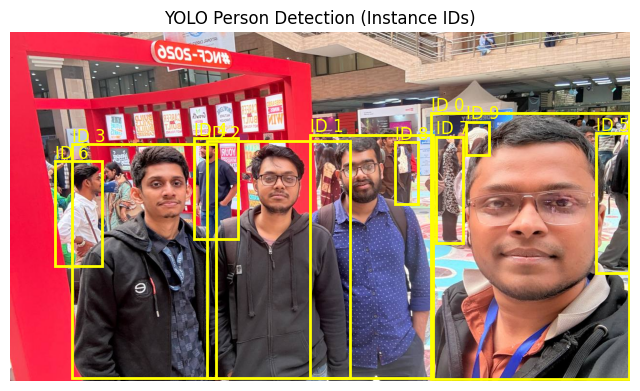

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image)

for i, box in enumerate(person_boxes):
    x1, y1, x2, y2 = box.astype(int)
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor='yellow',
            linewidth=2
        )
    )
    plt.text(x1, y1-5, f"ID {i}", color="yellow", fontsize=12)

plt.title("YOLO Person Detection (Instance IDs)")
plt.axis("off")
plt.show()


In [ ]:
click_x, click_y = 550, 300  # change slightly if needed


In [ ]:
selected_box = None

for box in person_boxes:
    x1, y1, x2, y2 = box.astype(int)
    if x1 <= click_x <= x2 and y1 <= click_y <= y2:
        selected_box = box
        break

print("Selected box:", selected_box)


Selected box: [     406.74      225.85       702.7      713.72]


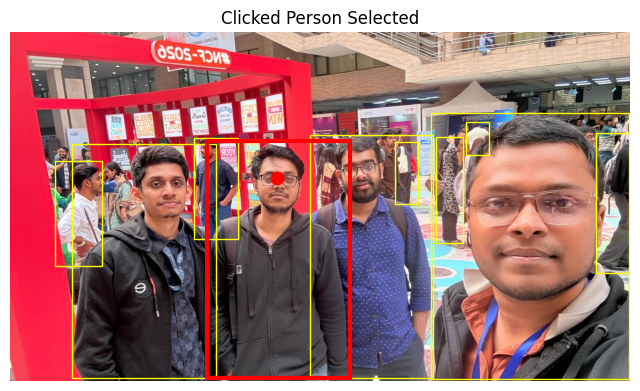

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image)

# draw all boxes
for box in person_boxes:
    x1, y1, x2, y2 = box.astype(int)
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor='yellow',
            linewidth=1
        )
    )

# highlight selected
if selected_box is not None:
    x1, y1, x2, y2 = selected_box.astype(int)
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor='red',
            linewidth=3
        )
    )

plt.scatter(click_x, click_y, c='red', s=80)
plt.title("Clicked Person Selected")
plt.axis("off")
plt.show()


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)
predictor = SamPredictor(sam)

predictor.set_image(image)


In [ ]:
input_box = selected_box.astype(int)

masks, scores, _ = predictor.predict(
    box=input_box[None, :],
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


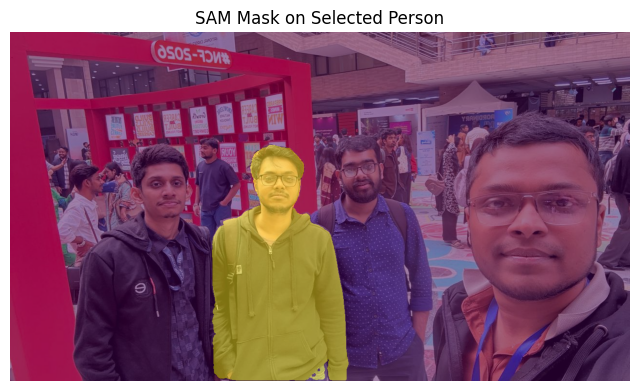

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.imshow(best_mask, alpha=0.5)
plt.title("SAM Mask on Selected Person")
plt.axis("off")
plt.show()


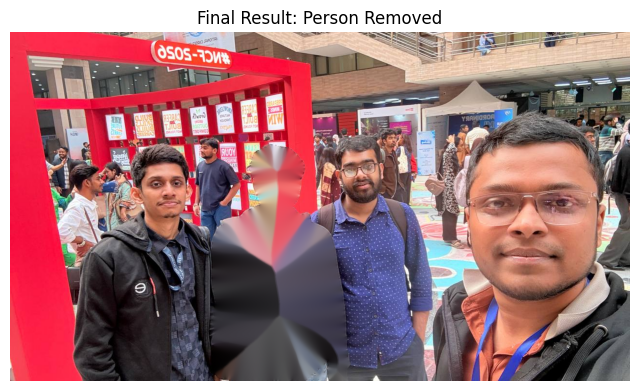

In [ ]:
mask_uint8 = (best_mask * 255).astype(np.uint8)

removed = cv2.inpaint(
    image,
    mask_uint8,
    inpaintRadius=5,
    flags=cv2.INPAINT_TELEA
)

plt.figure(figsize=(8,8))
plt.imshow(removed)
plt.title("Final Result: Person Removed")
plt.axis("off")
plt.show()
